In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import TensorDataset, DataLoader
import os
import warnings
warnings.filterwarnings('ignore')

# Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

TRAIN_SCENARIOS = list(range(1, 800))  # Adjust as needed
TEST_SCENARIO = 48
RANDOM_SEED = 123
DOWN_SAMPLE_FACTOR = 17
BATCH_SIZE = 8
EPOCHS = 200
LEARNING_RATE = 0.0003
PATIENCE = 30

# Set random seeds
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if device.type == 'cuda':
    torch.cuda.manual_seed(RANDOM_SEED)

# Your data loading function
def load_scenario_data(scenario_id, base_path=r"D:\LeakDB_full_data\Hanoi"):
    try:
        scenario_path = os.path.join(base_path, f"Scenario-{scenario_id}")
        if not os.path.exists(scenario_path):
            print(f"Scenario {scenario_id} not found.")
            return None
        
        leaks, timestamps = None, None
        demand_path = flow_path = pressure_path = None
        for sub in os.listdir(scenario_path):
            if sub in [f"Scenario-{scenario_id}", f"Scenario-{scenario_id}_info.csv", f"Hanoi_CMH_Scenario-{scenario_id}.inp"]:
                continue
            sub_path = os.path.join(scenario_path, sub)
            if sub == "Demands":
                demand_path = sub_path
            elif sub == "Flows":
                flow_path = sub_path
            elif sub == "Pressures":
                pressure_path = sub_path
            elif sub == "Labels.csv":
                leaks = pd.read_csv(sub_path).drop(columns=["Index"], errors="ignore")
            elif sub == "Timestamps.csv":
                timestamps = pd.read_csv(sub_path).drop(columns=["Index"], errors="ignore")

        if not all([demand_path, flow_path, pressure_path, leaks is not None, timestamps is not None]):
            print(f"Scenario {scenario_id} is incomplete.")
            return None

        df = pd.concat([leaks, timestamps], axis=1, ignore_index=True)
        df.columns = ["Leaks", "Timestamps"]

        def combined_feature_df(path, feature):
            dfs = []
            for file in sorted(os.listdir(path)):
                file_path = os.path.join(path, file)
                if not file.endswith(".csv"):
                    continue
                sub_df = pd.read_csv(file_path).drop(columns="Index", errors="ignore")
                sub_df.columns = [f"{feature}_{file.split('.')[0]}"]
                dfs.append(sub_df)
            return pd.concat(dfs, axis=1, ignore_index=True)

        demand_df = combined_feature_df(demand_path, "demand")
        pressure_df = combined_feature_df(pressure_path, "pressure")
        flow_df = combined_feature_df(flow_path, "flow")

        demand_df.columns = [f"demand_node_{i}" for i in range(1, demand_df.shape[1] + 1)]
        pressure_df.columns = [f"pressure_node_{i}" for i in range(1, pressure_df.shape[1] + 1)]
        flow_df.columns = [f"flow_link_{i}" for i in range(1, flow_df.shape[1] + 1)]

        final_df = pd.concat([demand_df, pressure_df, flow_df, df], axis=1)
        final_df["Leaks"] = final_df["Leaks"].astype(int)
        return final_df

    except Exception as e:
        print(f"Error loading scenario {scenario_id}: {e}")
        return None

# Feature extraction for binary classification
def extract_features_for_binary_classification(scenario_df):
    """
    Extract time-series features for binary leak detection
    Returns: features (np.array), has_leak (0 or 1)
    """
    try:
        # Extract feature columns (exclude Leaks and Timestamps)
        feature_columns = [col for col in scenario_df.columns if col not in ['Leaks', 'Timestamps']]
        features = scenario_df[feature_columns].values
        
        # Downsample
        time_steps = len(features)
        downsampled_len = time_steps // DOWN_SAMPLE_FACTOR
        features_downsampled = np.array([
            np.mean(features[i*DOWN_SAMPLE_FACTOR:(i+1)*DOWN_SAMPLE_FACTOR], axis=0) 
            for i in range(downsampled_len)
        ])
        
        # Determine if scenario has any leak (binary)
        has_leak = 1 if scenario_df['Leaks'].any() else 0
        
        return features_downsampled, has_leak
        
    except Exception as e:
        print(f"Error in feature extraction: {e}")
        return np.zeros((1, 98)), 0  # 98 features: 32 demand + 32 pressure + 34 flow

# Model Architecture for Binary Classification
class BinaryLeakDetectionModel(nn.Module):
    def __init__(self, input_dim):
        super(BinaryLeakDetectionModel, self).__init__()
        self.lstm1 = nn.LSTM(input_dim, 128, batch_first=True, bidirectional=True)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(0.4)
        
        self.lstm2 = nn.LSTM(256, 64, batch_first=True, bidirectional=True)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.4)
        
        self.fc1 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.dropout3 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(64, 32)
        self.bn4 = nn.BatchNorm1d(32)
        self.dropout4 = nn.Dropout(0.3)
        
        self.leak_detection_fc = nn.Linear(32, 1)
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.l2_reg = 0.001

    def forward(self, x):
        x, _ = self.lstm1(x)
        x = x[:, -1, :]  # Take last time step
        x = self.bn1(x)
        x = self.dropout1(x)
        
        x, _ = self.lstm2(x.unsqueeze(1))
        x = x[:, -1, :]
        x = self.bn2(x)
        x = self.dropout2(x)
        
        x = self.relu(self.fc1(x))
        x = self.bn3(x)
        x = self.dropout3(x)
        
        x = self.relu(self.fc2(x))
        x = self.bn4(x)
        x = self.dropout4(x)
        
        leak_detection = self.sigmoid(self.leak_detection_fc(x))
        return leak_detection

    def l2_regularization(self):
        l2_loss = 0
        for param in self.parameters():
            l2_loss += torch.norm(param, p=2) ** 2
        return self.l2_reg * l2_loss

# Data Preparation
print("Preparing training data...")

X_train_list = []
y_leak_detection = []

for scenario_idx in TRAIN_SCENARIOS:
    print(f"Processing Scenario {scenario_idx}...")
    try:
        scenario_df = load_scenario_data(scenario_idx)
        if scenario_df is not None:
            features, has_leak = extract_features_for_binary_classification(scenario_df)
            X_train_list.append(features)
            y_leak_detection.append(has_leak)
    except Exception as e:
        print(f"Error processing scenario {scenario_idx}: {e}")
        continue

# Pad sequences to same length
max_time = max(len(ts) for ts in X_train_list)
X_train_padded = np.array([
    np.pad(ts, ((0, max_time - len(ts)), (0, 0)), mode='constant') 
    for ts in X_train_list
])

print(f"Training data shape: {X_train_padded.shape}")
print(f"Training samples: {X_train_padded.shape[0]}")

# Standardize features
scaler = StandardScaler()
for i in range(X_train_padded.shape[2]):
    X_train_padded[:, :, i] = scaler.fit_transform(
        X_train_padded[:, :, i].reshape(-1, 1)
    ).reshape(X_train_padded.shape[0], -1)

# Calculate class weights
class_weights_detection = compute_class_weight(
    'balanced', 
    classes=np.unique(y_leak_detection), 
    y=y_leak_detection
)
class_weights_detection = dict(zip(np.unique(y_leak_detection), class_weights_detection))
class_weights_detection[1] *= 1.5  # Give more weight to leak class

print(f"Leaks in training data: {sum(y_leak_detection)}/{len(y_leak_detection)}")

# Convert to tensors
X_train_tensor = torch.tensor(X_train_padded, dtype=torch.float32).to(device)
y_leak_detection_tensor = torch.tensor(y_leak_detection, dtype=torch.float32).to(device)

# Create data loaders
dataset = TensorDataset(X_train_tensor, y_leak_detection_tensor)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
full_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

# Initialize model
input_dim = X_train_padded.shape[2]  # 98 features
model = BinaryLeakDetectionModel(input_dim=input_dim).to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6)

print(f"\nBinary Leak Detection Model:")
print(model)

# Training
print(f"\nStarting Training...")
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # Training
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        x, y_det = [b.to(device) for b in batch]
        
        optimizer.zero_grad()
        det_pred = model(x)
        
        loss = criterion(det_pred.squeeze(), y_det) + model.l2_regularization()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item() * x.size(0)
    
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_preds, val_true = [], []
    
    with torch.no_grad():
        for batch in val_loader:
            x, y_det = [b.to(device) for b in batch]
            det_pred = model(x)
            
            loss = criterion(det_pred.squeeze(), y_det) + model.l2_regularization()
            val_loss += loss.item() * x.size(0)
            
            val_preds.append(det_pred.cpu().numpy())
            val_true.append(y_det.cpu().numpy())
    
    val_loss /= len(val_dataset)
    val_losses.append(val_loss)
    
    val_preds = np.concatenate(val_preds).flatten()
    val_true = np.concatenate(val_true)
    val_acc = accuracy_score(val_true, (val_preds > 0.5).astype(int))
    
    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        
    if patience_counter >= PATIENCE:
        print("Early stopping triggered")
        break
    
    scheduler.step(val_loss)

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print("\nTraining completed!")

# Testing
print(f"\nTesting on Scenario {TEST_SCENARIO}...")

test_df = load_scenario_data(TEST_SCENARIO)
if test_df is None:
    print(f"Test scenario {TEST_SCENARIO} not found, using scenario 10")
    TEST_SCENARIO = 10
    test_df = load_scenario_data(TEST_SCENARIO)

test_features, test_has_leak = extract_features_for_binary_classification(test_df)

# Prepare test data
X_test = np.array([np.pad(test_features, ((0, max_time - len(test_features)), (0, 0)), mode='constant')])

for i in range(X_test.shape[2]):
    X_test[:, :, i] = scaler.transform(
        X_test[:, :, i].reshape(-1, 1)
    ).reshape(X_test.shape[0], -1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

# Prediction
model.eval()
with torch.no_grad():
    test_pred = model(X_test_tensor)

pred_leak_prob = test_pred.cpu().numpy()[0, 0]
pred_has_leak = pred_leak_prob > 0.5

# Results
print(f"\nTest Scenario {TEST_SCENARIO} Results:")
print(f"Predicted Leak Probability: {pred_leak_prob:.4f}")
print(f"Predicted Leak: {'YES' if pred_has_leak else 'NO'}")
print(f"Actual Leak: {'YES' if test_has_leak else 'NO'}")
print(f"Leak Detection Correct: {'YES' if pred_has_leak == test_has_leak else 'NO'}")

# Evaluation on training set
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for batch in full_loader:
        x, y_det = [b.to(device) for b in batch]
        pred = model(x)
        all_preds.append(pred.cpu().numpy())
        all_true.append(y_det.cpu().numpy())

all_preds = np.concatenate(all_preds).flatten()
all_true = np.concatenate(all_true)
all_pred_binary = (all_preds > 0.5).astype(int)

print(f"\nOverall Training Set Evaluation:")
print(f"Accuracy: {accuracy_score(all_true, all_pred_binary):.4f}")
print(f"Precision: {precision_score(all_true, all_pred_binary, zero_division=0):.4f}")
print(f"Recall: {recall_score(all_true, all_pred_binary, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(all_true, all_pred_binary, zero_division=0):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(all_true, all_pred_binary)}")

Using device: cuda
Preparing training data...
Processing Scenario 1...
Processing Scenario 2...
Processing Scenario 3...
Processing Scenario 4...
Processing Scenario 5...
Processing Scenario 6...
Processing Scenario 7...
Processing Scenario 8...
Processing Scenario 9...
Processing Scenario 10...
Processing Scenario 11...
Processing Scenario 12...
Processing Scenario 13...
Processing Scenario 14...
Processing Scenario 15...
Processing Scenario 16...
Processing Scenario 17...
Processing Scenario 18...
Processing Scenario 19...
Processing Scenario 20...
Processing Scenario 21...
Processing Scenario 22...
Processing Scenario 23...
Processing Scenario 24...
Processing Scenario 25...
Processing Scenario 26...
Processing Scenario 27...
Processing Scenario 28...
Processing Scenario 29...
Processing Scenario 30...
Processing Scenario 31...
Processing Scenario 32...
Processing Scenario 33...
Processing Scenario 34...
Processing Scenario 35...
Processing Scenario 36...
Processing Scenario 37...
P

In [2]:
def test_single_scenario(model, scaler, scenario_id, base_path=r"D:\LeakDB_full_data\Hanoi"):
    """
    Test a single scenario and return detailed results
    
    Args:
        model: Trained PyTorch model
        scaler: Fitted StandardScaler
        scenario_id: ID of the scenario to test
        base_path: Base path to scenario data
    
    Returns:
        dict: Test results including prediction, probability, and actual label
    """
    # Load scenario data
    scenario_df = load_scenario_data(scenario_id, base_path)
    if scenario_df is None:
        print(f"Scenario {scenario_id} not found or incomplete")
        return None
    
    # Extract features and label
    test_features, actual_has_leak = extract_features_for_binary_classification(scenario_df)
    
    # Prepare test data (using global max_time from training)
    global max_time  # This should be available from training
    X_test = np.array([np.pad(test_features, ((0, max_time - len(test_features)), (0, 0)), mode='constant')])
    
    # Standardize using the same scaler from training
    for i in range(X_test.shape[2]):
        X_test[:, :, i] = scaler.transform(
            X_test[:, :, i].reshape(-1, 1)
        ).reshape(X_test.shape[0], -1)
    
    # Convert to tensor
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    
    # Prediction
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test_tensor)
    
    pred_leak_prob = test_pred.cpu().numpy()[0, 0]
    pred_has_leak = pred_leak_prob > 0.5
    
    # Calculate additional metrics
    confidence = pred_leak_prob if pred_has_leak else (1 - pred_leak_prob)
    
    # Create results dictionary
    results = {
        'scenario_id': scenario_id,
        'predicted_probability': float(pred_leak_prob),
        'predicted_leak': bool(pred_has_leak),
        'actual_leak': bool(actual_has_leak),
        'correct': bool(pred_has_leak == actual_has_leak),
        'confidence': float(confidence),
        'leak_timestamps': int(scenario_df['Leaks'].sum()) if actual_has_leak else 0,
        'total_timestamps': len(scenario_df)
    }
    
    return results

def print_test_results(results):
    """Pretty print the test results"""
    if results is None:
        print("No results to display")
        return
    
    print(f"\n{'='*60}")
    print(f"TEST RESULTS - SCENARIO {results['scenario_id']}")
    print(f"{'='*60}")
    
    print(f"Predicted Leak Probability: {results['predicted_probability']:.4f}")
    print(f"Predicted: {'LEAK DETECTED' if results['predicted_leak'] else 'NO LEAK'}")
    print(f"Actual: {'LEAK DETECTED' if results['actual_leak'] else 'NO LEAK'}")
    print(f"Confidence: {results['confidence']:.2%}")
    
    if results['actual_leak']:
        print(f"Leak Timestamps: {results['leak_timestamps']}/{results['total_timestamps']}")
    
    print(f"\nResult: {'✓ CORRECT' if results['correct'] else '✗ INCORRECT'}")
    print(f"{'='*60}")

# Usage examples after training:
def test_multiple_scenarios(model, scaler, scenario_ids):
    """Test multiple scenarios and return summary statistics"""
    results_list = []
    
    for scenario_id in scenario_ids:
        print(f"Testing Scenario {scenario_id}...")
        result = test_single_scenario(model, scaler, scenario_id)
        if result is not None:
            results_list.append(result)
            print_test_results(result)
    
    # Print summary
    if results_list:
        correct_predictions = sum(1 for r in results_list if r['correct'])
        total_predictions = len(results_list)
        accuracy = correct_predictions / total_predictions
        
        print(f"\n{'='*60}")
        print(f"SUMMARY - {total_predictions} SCENARIOS")
        print(f"{'='*60}")
        print(f"Accuracy: {accuracy:.2%} ({correct_predictions}/{total_predictions})")
        
        # Breakdown by actual class
        actual_leaks = [r for r in results_list if r['actual_leak']]
        actual_no_leaks = [r for r in results_list if not r['actual_leak']]
        
        if actual_leaks:
            leak_accuracy = sum(1 for r in actual_leaks if r['correct']) / len(actual_leaks)
            print(f"Leak Detection Accuracy: {leak_accuracy:.2%}")
        
        if actual_no_leaks:
            no_leak_accuracy = sum(1 for r in actual_no_leaks if r['correct']) / len(actual_no_leaks)
            print(f"No-Leak Accuracy: {no_leak_accuracy:.2%}")
    
    return results_list

# Add this to your main code after training:
if __name__ == "__main__":
    # After training is complete, you can test individual scenarios:
    
    # Test the specific test scenario
    test_result = test_single_scenario(model, scaler, TEST_SCENARIO)
    print_test_results(test_result)
    
    # Test multiple scenarios
    test_scenarios = [1, 2, 5, 10, 48, 100]  # Example scenarios
    all_results = test_multiple_scenarios(model, scaler, test_scenarios)
    
    # You can also test a single scenario interactively:
    # while True:
    #     try:
    #         scenario_id = int(input("\nEnter scenario ID to test (or 0 to exit): "))
    #         if scenario_id == 0:
    #             break
    #         result = test_single_scenario(model, scaler, scenario_id)
    #         print_test_results(result)
    #     except ValueError:
    #         print("Please enter a valid number")
    #     except Exception as e:
    #         print(f"Error testing scenario: {e}")


TEST RESULTS - SCENARIO 48
Predicted Leak Probability: 0.9244
Predicted: LEAK DETECTED
Actual: NO LEAK
Confidence: 92.44%

Result: ✗ INCORRECT
Testing Scenario 1...

TEST RESULTS - SCENARIO 1
Predicted Leak Probability: 0.9262
Predicted: LEAK DETECTED
Actual: NO LEAK
Confidence: 92.62%

Result: ✗ INCORRECT
Testing Scenario 2...

TEST RESULTS - SCENARIO 2
Predicted Leak Probability: 0.9251
Predicted: LEAK DETECTED
Actual: LEAK DETECTED
Confidence: 92.51%
Leak Timestamps: 826/17520

Result: ✓ CORRECT
Testing Scenario 5...

TEST RESULTS - SCENARIO 5
Predicted Leak Probability: 0.9025
Predicted: LEAK DETECTED
Actual: NO LEAK
Confidence: 90.25%

Result: ✗ INCORRECT
Testing Scenario 10...

TEST RESULTS - SCENARIO 10
Predicted Leak Probability: 0.9134
Predicted: LEAK DETECTED
Actual: NO LEAK
Confidence: 91.34%

Result: ✗ INCORRECT
Testing Scenario 48...

TEST RESULTS - SCENARIO 48
Predicted Leak Probability: 0.9244
Predicted: LEAK DETECTED
Actual: NO LEAK
Confidence: 92.44%

Result: ✗ INCORR

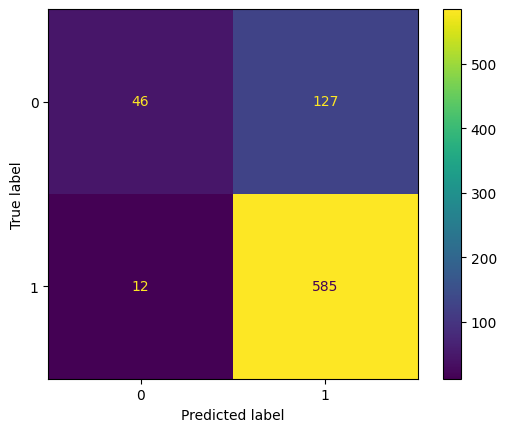

In [4]:
import matplotlib.pyplot as plt 
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix(all_true, all_pred_binary))
disp.plot()
plt.show()